In [2]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

## Open Scan files

In [3]:
GAMBIT_RANDOM = "FS_MSSM7atQ_random_gambit.hdf5"
GAMBIT_DIVER = "FS_MSSM7atQ_diver_gambit.hdf5"
MODELGEN = "SP_MSSM7atQ_random_modelgen.hdf5"
VERSION = "v5"

In [4]:
def open_scan(file_name: str, version: str = VERSION) -> h5py.File:
    """open a scan file and return the h5py File object"""
    if "modelgen" in file_name.lower():
        file_path = f"../data/modelgen-output/modelgen-{version}/{file_name}"
    elif "gambit" in file_name.lower():
        file_path = f"../data/gambit-output/gambit-{version}/{file_name}"
    else:
        raise ValueError("File name must contain 'modelgen' or 'gambit'\nNAMING CONVENTION: <framework>-<version>/<filename>")

    return h5py.File(file_path, "r")["MSSM"]

In [5]:
scan_modelgen = open_scan(MODELGEN)
scan_gambit_random = open_scan(GAMBIT_RANDOM)
scan_gambit_diver = open_scan(GAMBIT_DIVER)

## Select Parameter

In [6]:
parameter = "#MSSM_spectrum @SpecBit::get_MSSM_spectrum_as_map::M1 mass1"

In [7]:
def parameter_lookup(parameter: str, conversion_table: str = "conversion_table.txt") -> str:
    """
    For any givern parameter look up its counterpart (GAMBIT <-> MODELGEN) in the conversion table.
    If the parameter is not found ask the user for the counterpart and add it to the table.

    returns: str (gambit-parameter;modelgen-parameter)
    """
    parameter_type = "gambit" if len(parameter.split(" ")) > 1 else "modelgen"

    def add_conversion_entry():
        if parameter_type == "gambit":
            gambit_par = parameter
            modelgen_par = input(f"enter the corresponding MODELGEN parameter name for {parameter}").strip()
        if parameter_type == "modelgen":
            gambit_par = input(f"enter the corresponding GAMBIT parameter name for {parameter}").strip()
            modelgen_par = parameter
        parameter_pair = "\n" + gambit_par + ";" + modelgen_par
        with open(conversion_table, "a") as file:
            file.write(parameter_pair)
        return parameter_pair.strip()

    if not os.path.isfile(conversion_table):
        parameter_pair = add_conversion_entry()
        return parameter_pair

    with open(conversion_table, "r") as file:
        for line in file:
            if parameter in line:
                parameter_pair = line.strip()
                return parameter_pair
            
    parameter_pair = add_conversion_entry()
    return parameter_pair
        


In [10]:
parameter_pair = parameter_lookup(parameter).split(";")
data_gambit_random = scan_gambit_random[parameter_pair[0]][scan_gambit_random[parameter_pair[0] + "_isvalid"][:] == 1]
data_gambit_diver = scan_gambit_diver[parameter_pair[0]][scan_gambit_diver[parameter_pair[0] + "_isvalid"][:] == 1]
data_modelgen = scan_modelgen[parameter_pair[1]][scan_modelgen[parameter_pair[1]][:] != -1]
parameter_pair


['#MSSM_spectrum @SpecBit::get_MSSM_spectrum_as_map::M1 mass1', 'SP_M_1']

## Create Plot

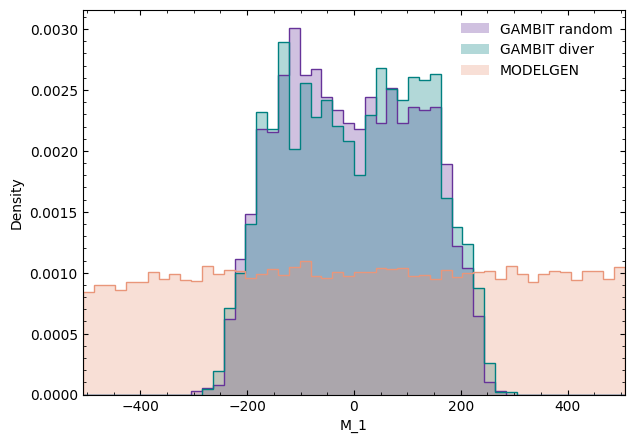

In [9]:
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111)
hist_range = (
    min([np.min(data_gambit_random), np.min(data_gambit_diver), np.min(data_modelgen)]),
    max([np.max(data_gambit_random), np.max(data_gambit_diver), np.max(data_modelgen)])
    )

ax.hist(data_gambit_random, bins=50, range=hist_range, density=True, alpha=0.3, histtype='stepfilled', color='rebeccapurple', label="GAMBIT random")
ax.hist(data_gambit_random, bins=50, range=hist_range, density=True, histtype='step', color='rebeccapurple')
ax.hist(data_gambit_diver, bins=50, range=hist_range, density=True, alpha=0.3, histtype='stepfilled', color='teal', label="GAMBIT diver")
ax.hist(data_gambit_diver, bins=50, range=hist_range, density=True, histtype='step', color='teal')
ax.hist(data_modelgen, bins=50, range=hist_range, density=True, alpha=0.3, histtype='stepfilled', color='darksalmon', label="MODELGEN")
ax.hist(data_modelgen, bins=50, range=hist_range, density=True, histtype='step', color='darksalmon')


ax.set_xlabel(parameter_pair[1][parameter_pair[1].find("_")+1:])
ax.set_ylabel("Density")

ax.set_xlim(hist_range)
ax.minorticks_on()
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax.legend(frameon=False)

plt.show()